# Capítulo 14 — Regresión: predecir valores numéricos

Hasta ahora trabajamos principalmente con problemas de clasificación. En este cuaderno cambiaremos el tipo de pregunta: en lugar de elegir una categoría, estudiaremos situaciones en las que necesitamos estimar una cantidad.

La práctica se concentrará en reconocer problemas de regresión, definir una variable objetivo numérica e interpretar errores de predicción. Todavía no entrenaremos un modelo: la regresión lineal y las métricas específicas se desarrollarán en los capítulos siguientes.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir problemas de clasificación y de regresión;
- reconocer cuándo una variable numérica representa una cantidad;
- diferenciar cantidades, categorías codificadas e identificadores;
- construir `X` e `y` para un problema de regresión;
- calcular el error con signo y el error absoluto de cada predicción;
- identificar subestimaciones y sobreestimaciones;
- interpretar los errores en las unidades del problema;
- explicar qué información puede perderse al convertir una cantidad en categorías.


## 1. Importar las herramientas

Usaremos Pandas y NumPy para organizar los datos y Matplotlib para representar valores reales, predicciones y errores.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. ¿Clasificación o regresión?

El tipo de problema depende de la pregunta y del significado de `y`, no del tema general del dataset. Con datos de viviendas, por ejemplo, podríamos predecir un precio o una categoría de precio.

Construiremos una tabla con situaciones diferentes.


In [2]:
problemas = pd.DataFrame({
    "pregunta": [
        "¿Cuál será el precio de la vivienda?",
        "¿La vivienda pertenece al rango de precio alto?",
        "¿Cuántas unidades se venderán mañana?",
        "¿La demanda será baja, media o alta?",
        "¿Cuánto tardará una entrega?",
        "¿La entrega llegará tarde?",
    ],
    "salida_esperada": [
        "128000 dólares",
        "Sí / No",
        "850 unidades",
        "Baja / Media / Alta",
        "42 minutos",
        "Sí / No",
    ],
    "tipo_de_problema": [
        "Regresión",
        "Clasificación",
        "Regresión",
        "Clasificación",
        "Regresión",
        "Clasificación",
    ],
})

problemas


,pregunta,salida_esperada,tipo_de_problema
0,¿Cuál será el precio de la vivienda?,128000 dólares,Regresión
1,¿La vivienda pertenece al rango de precio alto?,Sí / No,Clasificación
2,¿Cuántas unidades se venderán mañana?,850 unidades,Regresión
3,"¿La demanda será baja, media o alta?",Baja / Media / Alta,Clasificación
4,¿Cuánto tardará una entrega?,42 minutos,Regresión
5,¿La entrega llegará tarde?,Sí / No,Clasificación


Los pares de preguntas se refieren a fenómenos parecidos, pero no producen la misma salida:

- la regresión conserva una cantidad numérica;
- la clasificación asigna una categoría.

Antes de elegir un algoritmo debemos decidir qué información necesita la persona que usará el resultado.


## 3. No todo número representa una cantidad

Una columna puede tener tipo numérico en un DataFrame y, sin embargo, no ser un objetivo adecuado para regresión. Observemos algunos ejemplos.


In [3]:
columnas_numericas = pd.DataFrame({
    "columna": [
        "precio",
        "temperatura",
        "unidades_vendidas",
        "nivel_riesgo",
        "codigo_postal",
        "id_cliente",
    ],
    "ejemplos": [
        "85000, 123500, 240000",
        "18.5, 24.0, 31.7",
        "120, 138, 155",
        "0, 1, 2",
        "1425, 1704, 5000",
        "839102, 839103, 839104",
    ],
    "significado": [
        "Cantidad monetaria",
        "Cantidad física",
        "Conteo",
        "Categoría codificada",
        "Identificador geográfico",
        "Identificador",
    ],
    "¿posible_objetivo_de_regresión?": [
        "Sí",
        "Sí",
        "Sí",
        "No necesariamente",
        "No",
        "No",
    ],
})

columnas_numericas


,columna,ejemplos,significado,¿posible_objetivo_de_regresión?
0,precio,"85000, 123500, 240000",Cantidad monetaria,Sí
1,temperatura,"18.5, 24.0, 31.7",Cantidad física,Sí
2,unidades_vendidas,"120, 138, 155",Conteo,Sí
3,nivel_riesgo,"0, 1, 2",Categoría codificada,No necesariamente
4,codigo_postal,"1425, 1704, 5000",Identificador geográfico,No
5,id_cliente,"839102, 839103, 839104",Identificador,No


La presencia de decimales tampoco decide el tipo de problema. `unidades_vendidas` contiene enteros, pero representa una magnitud. En cambio, un código postal está formado por números, aunque una diferencia de 10 entre dos códigos no representa un error cuantitativo.

La pregunta clave es:

```text
¿Tiene sentido interpretar la distancia entre dos valores?
```


## 4. Preparar un conjunto de datos de viviendas

Trabajaremos con un dataset didáctico de veinte viviendas. Los valores fueron creados para este cuaderno y no representan tasaciones reales.


In [4]:
viviendas = pd.DataFrame({
    "id_vivienda": [
        f"V{i:03d}" for i in range(1, 21)
    ],
    "superficie_m2": [
        50, 60, 75, 90, 110,
        48, 68, 85, 100, 120,
        55, 72, 95, 105, 130,
        45, 80, 115, 140, 65,
    ],
    "ambientes": [
        2, 2, 3, 4, 4,
        2, 3, 3, 4, 5,
        2, 3, 4, 4, 5,
        1, 3, 4, 5, 2,
    ],
    "antiguedad_anios": [
        35, 25, 20, 12, 8,
        40, 30, 15, 10, 5,
        18, 22, 28, 7, 3,
        50, 16, 9, 2, 12,
    ],
    "distancia_centro_km": [
        8.0, 6.5, 5.0, 4.0, 3.0,
        10.0, 7.0, 2.5, 6.0, 1.5,
        12.0, 9.0, 5.5, 2.0, 4.5,
        14.0, 8.0, 3.5, 6.0, 11.0,
    ],
    "barrio": [
        "Oeste", "Centro", "Norte", "Sur", "Centro",
        "Sur", "Oeste", "Centro", "Norte", "Centro",
        "Sur", "Oeste", "Norte", "Centro", "Norte",
        "Sur", "Oeste", "Centro", "Norte", "Sur",
    ],
    "precio_usd": [
        70000, 82000, 98000, 118000, 140000,
        65000, 88000, 125000, 132000, 180500,
        72000, 91000, 121000, 158000, 190000,
        58000, 103000, 170000, 205000, 86000,
    ],
})

viviendas.head()


,id_vivienda,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio,precio_usd
0,V001,50,2,35,8.0,Oeste,70000
1,V002,60,2,25,6.5,Centro,82000
2,V003,75,3,20,5.0,Norte,98000
3,V004,90,4,12,4.0,Sur,118000
4,V005,110,4,8,3.0,Centro,140000


Cada fila describe una vivienda. `precio_usd` es una cantidad monetaria y puede tomar muchos valores, por lo que resulta una variable objetivo natural para un problema de regresión.


In [5]:
pd.DataFrame({
    "filas": [viviendas.shape[0]],
    "columnas": [viviendas.shape[1]],
    "precio_mínimo": [
        viviendas["precio_usd"].min()
    ],
    "precio_máximo": [
        viviendas["precio_usd"].max()
    ],
    "valores_faltantes": [
        viviendas.isna().sum().sum()
    ],
})


,filas,columnas,precio_mínimo,precio_máximo,valores_faltantes
0,20,7,58000,205000,0


El conjunto contiene veinte observaciones completas. Los precios se encuentran entre 58000 y 205000 dólares. Estas unidades y este rango serán necesarios para interpretar cualquier error de predicción.


## 5. Construir `X` e `y`

La estructura del aprendizaje supervisado sigue siendo la misma:

```text
datos históricos: conocemos X y conocemos y
caso nuevo:        conocemos X y queremos estimar y
```

En este ejemplo excluimos el identificador porque solo nombra cada fila.


In [6]:
variables_entrada = [
    "superficie_m2",
    "ambientes",
    "antiguedad_anios",
    "distancia_centro_km",
    "barrio",
]

X = viviendas[variables_entrada]
y = viviendas["precio_usd"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombre de y:", y.name)


Forma de X: (20, 5)
Forma de y: (20,)
Nombre de y: precio_usd


`X` contiene cinco variables de entrada para cada vivienda. `y` contiene un único precio observado por fila. A diferencia de los capítulos de clasificación, sus valores no son etiquetas como `0` y `1`, sino cantidades monetarias.


In [7]:
pd.concat(
    [
        X.head(4),
        y.head(4),
    ],
    axis=1,
)


,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio,precio_usd
0,50,2,35,8.0,Oeste,70000
1,60,2,25,6.5,Centro,82000
2,75,3,20,5.0,Norte,98000
3,90,4,12,4.0,Sur,118000


La correspondencia por filas es esencial: las características de cada vivienda deben permanecer asociadas con su precio real.


### Un caso nuevo

Para una vivienda nueva conoceríamos sus variables de entrada, pero no su precio real. La salida futura de un modelo de regresión sería un número estimado.


In [8]:
X_nuevo = pd.DataFrame({
    "superficie_m2": [88],
    "ambientes": [3],
    "antiguedad_anios": [11],
    "distancia_centro_km": [4.5],
    "barrio": ["Norte"],
})

X_nuevo


,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio
0,88,3,11,4.5,Norte


Todavía no calcularemos un precio para este caso. En el próximo capítulo estudiaremos la regresión lineal y podremos entrenar un modelo que produzca esa estimación.


## 6. Interpretar predicciones numéricas

Supongamos que un modelo ya produjo precios estimados para ocho viviendas. Usaremos esas salidas para estudiar el error, sin analizar todavía cómo se generaron.

Definiremos:

```text
error = valor real - valor predicho
error absoluto = |valor real - valor predicho|
```


In [9]:
indices_evaluados = [
    2, 4, 7, 9, 12, 14, 17, 18
]

evaluacion = viviendas.loc[
    indices_evaluados,
    [
        "id_vivienda",
        "superficie_m2",
        "precio_usd",
    ],
].copy()

evaluacion["precio_predicho_usd"] = [
    96000,
    147000,
    121000,
    180500,
    126000,
    175000,
    181000,
    198000,
]

evaluacion["error"] = (
    evaluacion["precio_usd"]
    - evaluacion["precio_predicho_usd"]
)
evaluacion["error_absoluto"] = (
    evaluacion["error"].abs()
)

evaluacion["dirección"] = np.select(
    [
        evaluacion["error"] > 0,
        evaluacion["error"] < 0,
    ],
    [
        "Subestimación",
        "Sobreestimación",
    ],
    default="Predicción exacta",
)

evaluacion.reset_index(drop=True)


,id_vivienda,superficie_m2,precio_usd,precio_predicho_usd,error,error_absoluto,dirección
0,V003,75,98000,96000,2000,2000,Subestimación
1,V005,110,140000,147000,-7000,7000,Sobreestimación
2,V008,85,125000,121000,4000,4000,Subestimación
3,V010,120,180500,180500,0,0,Predicción exacta
4,V013,95,121000,126000,-5000,5000,Sobreestimación
5,V015,130,190000,175000,15000,15000,Subestimación
6,V018,115,170000,181000,-11000,11000,Sobreestimación
7,V019,140,205000,198000,7000,7000,Subestimación


El signo conserva la dirección del error:

- un error positivo indica que el precio predicho quedó por debajo del real;
- un error negativo indica que el precio predicho quedó por encima del real;
- un error igual a cero indica coincidencia exacta.

El error absoluto elimina el signo y conserva únicamente la magnitud de la diferencia.


In [10]:
evaluacion["dirección"].value_counts().to_frame(
    "cantidad"
)


,cantidad
dirección,
Subestimación,4
Sobreestimación,3
Predicción exacta,1


En estas ocho observaciones hay cuatro subestimaciones, tres sobreestimaciones y una coincidencia exacta. Contar las direcciones permite detectar una posible tendencia, aunque este ejemplo pequeño no alcanza para afirmar que el modelo tenga un sesgo sistemático.


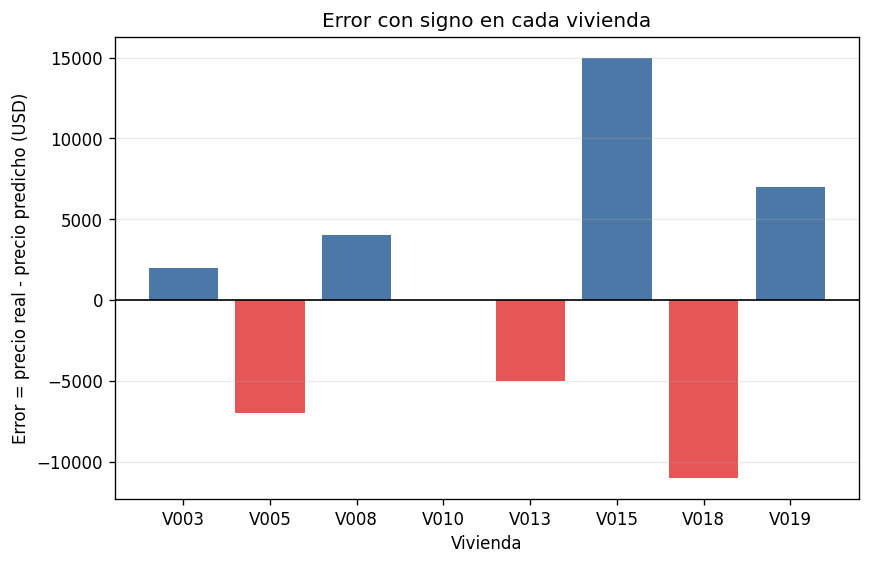

In [11]:
colores = np.where(
    evaluacion["dirección"] == "Subestimación",
    "#4C78A8",
    np.where(
        evaluacion["dirección"] == "Sobreestimación",
        "#E45756",
        "#72B7B2",
    ),
)

plt.figure(figsize=(8, 5))
plt.bar(
    evaluacion["id_vivienda"],
    evaluacion["error"],
    color=colores,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Error con signo en cada vivienda")
plt.xlabel("Vivienda")
plt.ylabel(
    "Error = precio real - precio predicho (USD)"
)
plt.grid(axis="y", alpha=0.25)
plt.show()


Las barras por encima de cero representan subestimaciones y las que quedan por debajo, sobreestimaciones. La altura muestra cuánto se alejó cada predicción del valor real.

La vivienda `V015` presenta la mayor subestimación del grupo: el modelo predijo 15000 dólares menos que el precio observado.


## 7. Comparar valores reales y predichos

Otra visualización útil consiste en ubicar el valor real y el predicho en los dos ejes. La línea diagonal representa predicciones exactas.


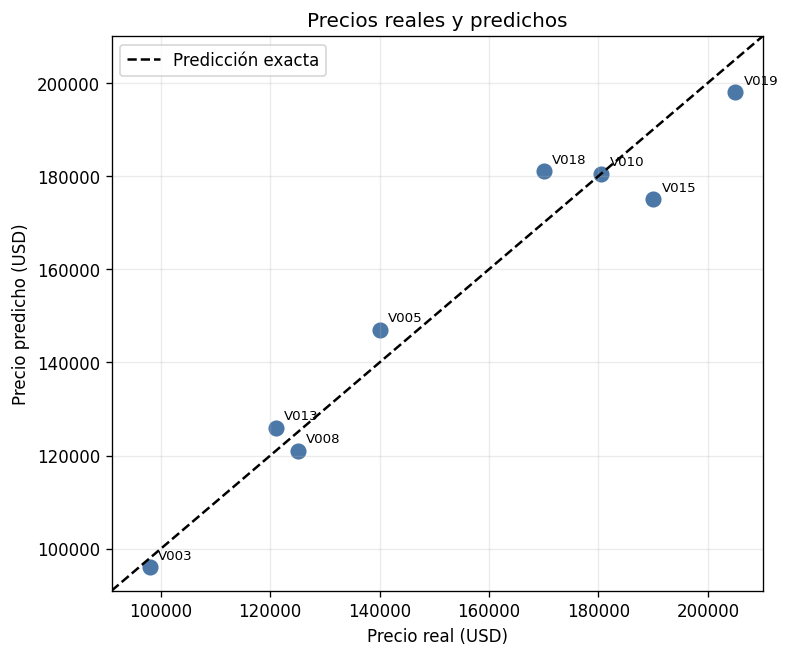

In [12]:
limite_inferior = min(
    evaluacion["precio_usd"].min(),
    evaluacion["precio_predicho_usd"].min(),
) - 5000
limite_superior = max(
    evaluacion["precio_usd"].max(),
    evaluacion["precio_predicho_usd"].max(),
) + 5000

plt.figure(figsize=(7, 6))
plt.scatter(
    evaluacion["precio_usd"],
    evaluacion["precio_predicho_usd"],
    s=75,
    color="#4C78A8",
)
plt.plot(
    [limite_inferior, limite_superior],
    [limite_inferior, limite_superior],
    linestyle="--",
    color="black",
    label="Predicción exacta",
)

for _, fila in evaluacion.iterrows():
    plt.annotate(
        fila["id_vivienda"],
        (
            fila["precio_usd"],
            fila["precio_predicho_usd"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlim(limite_inferior, limite_superior)
plt.ylim(limite_inferior, limite_superior)
plt.title("Precios reales y predichos")
plt.xlabel("Precio real (USD)")
plt.ylabel("Precio predicho (USD)")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


Cuanto más cerca queda un punto de la diagonal, menor es su error absoluto. Los puntos por encima de la línea son sobreestimaciones; los puntos por debajo son subestimaciones.

Este gráfico permite comparar errores de manera visual, pero todavía no resume el desempeño en una métrica única.


## 8. El error depende de las unidades y del contexto

El número `10` no tiene el mismo significado en todos los problemas. Compararemos errores absolutos iguales expresados en unidades diferentes.


In [13]:
errores_contexto = pd.DataFrame({
    "problema": [
        "Precio de una vivienda",
        "Temperatura máxima",
        "Ventas diarias",
        "Tiempo de entrega",
    ],
    "unidad": [
        "dólares",
        "grados Celsius",
        "unidades",
        "minutos",
    ],
    "valor_real": [
        150000,
        28,
        1000,
        40,
    ],
    "valor_predicho": [
        149990,
        18,
        990,
        30,
    ],
})

errores_contexto["error_absoluto"] = (
    errores_contexto["valor_real"]
    - errores_contexto["valor_predicho"]
).abs()

errores_contexto


,problema,unidad,valor_real,valor_predicho,error_absoluto
0,Precio de una vivienda,dólares,150000,149990,10
1,Temperatura máxima,grados Celsius,28,18,10
2,Ventas diarias,unidades,1000,990,10
3,Tiempo de entrega,minutos,40,30,10


Los cuatro errores absolutos valen `10`, pero sus consecuencias pueden ser muy distintas. Diez dólares pueden resultar irrelevantes al tasar una vivienda; diez grados pueden volver inútil una predicción meteorológica.

Una diferencia numérica nunca debe interpretarse sin conocer la unidad, la escala y el uso de la predicción.


## 9. Revisar valores extremos

Los valores extremos pueden ser errores de carga, casos excepcionales o situaciones reales importantes. No deben eliminarse automáticamente.


In [14]:
viviendas_extremo = viviendas[[
    "id_vivienda",
    "precio_usd",
]].copy()

viviendas_extremo.loc[
    len(viviendas_extremo)
] = [
    "V021",
    420000,
]

viviendas_extremo.tail()


,id_vivienda,precio_usd
16,V017,103000
17,V018,170000
18,V019,205000
19,V020,86000
20,V021,420000


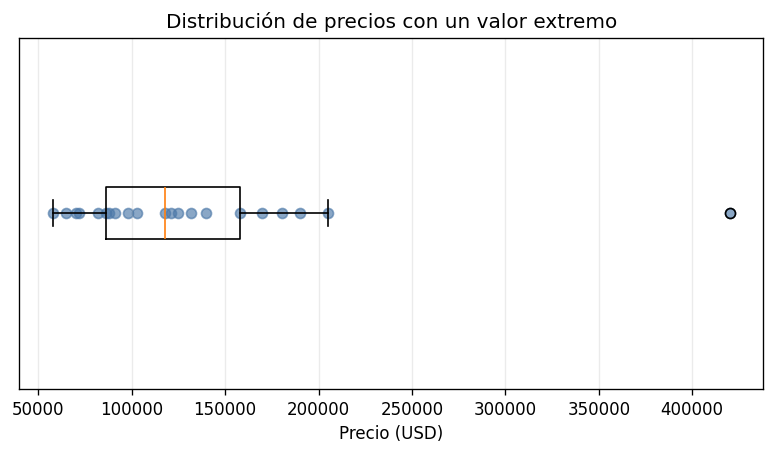

In [15]:
plt.figure(figsize=(8, 3.8))
plt.boxplot(
    viviendas_extremo["precio_usd"],
    vert=False,
)
plt.scatter(
    viviendas_extremo["precio_usd"],
    np.ones(len(viviendas_extremo)),
    alpha=0.65,
    color="#4C78A8",
)
plt.title(
    "Distribución de precios con un valor extremo"
)
plt.xlabel("Precio (USD)")
plt.yticks([])
plt.grid(axis="x", alpha=0.25)
plt.show()


El precio de 420000 dólares queda separado del resto. El gráfico ayuda a detectarlo, pero no permite saber por sí solo si es incorrecto.

Antes de decidir qué hacer habría que consultar la fuente: podría tratarse de un error de carga o de una propiedad excepcional y válida.


## 10. ¿Qué se pierde al convertir cantidades en categorías?

Podríamos transformar los precios en tres grupos:

```text
hasta 100000          → precio bajo
más de 100000 a 180000 → precio medio
más de 180000         → precio alto
```

La clasificación resultante puede ser útil para algunas decisiones, pero ya no conserva el valor exacto o aproximado.


In [16]:
ejemplos_rangos = pd.DataFrame({
    "vivienda": [
        "A", "B", "C", "D", "E", "F"
    ],
    "precio_usd": [
        50000,
        99000,
        101000,
        179000,
        181000,
        400000,
    ],
})

ejemplos_rangos["rango"] = pd.cut(
    ejemplos_rangos["precio_usd"],
    bins=[
        -np.inf,
        100000,
        180000,
        np.inf,
    ],
    labels=[
        "Bajo",
        "Medio",
        "Alto",
    ],
)

ejemplos_rangos


,vivienda,precio_usd,rango
0,A,50000,Bajo
1,B,99000,Bajo
2,C,101000,Medio
3,D,179000,Medio
4,E,181000,Alto
5,F,400000,Alto


Las viviendas A y B comparten la categoría “Bajo” aunque sus precios difieren en 49000 dólares. En cambio, B y C difieren en solo 2000 dólares, pero quedan en categorías distintas.

Los límites crean fronteras artificiales y reducen el detalle de la información.


In [17]:
caso_frontera = pd.DataFrame({
    "valor_real": [101000],
    "valor_predicho": [99000],
})

caso_frontera["error_absoluto"] = (
    caso_frontera["valor_real"]
    - caso_frontera["valor_predicho"]
).abs()

caso_frontera["categoría_real"] = pd.cut(
    caso_frontera["valor_real"],
    bins=[-np.inf, 100000, 180000, np.inf],
    labels=["Bajo", "Medio", "Alto"],
)
caso_frontera["categoría_predicha"] = pd.cut(
    caso_frontera["valor_predicho"],
    bins=[-np.inf, 100000, 180000, np.inf],
    labels=["Bajo", "Medio", "Alto"],
)

caso_frontera


,valor_real,valor_predicho,error_absoluto,categoría_real,categoría_predicha
0,101000,99000,2000,Medio,Bajo


Como cantidades, los valores están separados por 2000 dólares. Como categorías, la predicción cambia de “Medio” a “Bajo” y se cuenta como una clase diferente.

Esto no significa que nunca debamos crear rangos. Significa que la decisión debe responder al uso real:

- si necesitamos estimar cuánto vale, conviene regresión;
- si necesitamos asignar un grupo con límites justificados, puede convenir clasificación.


## 11. Una pequeña exploración

Modificá las predicciones de la siguiente lista. Después ejecutá la celda y observá cómo cambian el signo, la magnitud y la dirección de cada error.

La actividad trabaja con errores individuales. Todavía no busca resumirlos mediante MAE, MSE, RMSE o R².


In [18]:
# Podés modificar estos ocho valores.
predicciones_actividad = [
    97000,
    143000,
    124000,
    179000,
    120000,
    188000,
    168000,
    210000,
]

actividad = evaluacion[[
    "id_vivienda",
    "precio_usd",
]].copy()

actividad["precio_predicho_usd"] = (
    predicciones_actividad
)
actividad["error"] = (
    actividad["precio_usd"]
    - actividad["precio_predicho_usd"]
)
actividad["error_absoluto"] = (
    actividad["error"].abs()
)
actividad["dirección"] = np.select(
    [
        actividad["error"] > 0,
        actividad["error"] < 0,
    ],
    [
        "Subestimación",
        "Sobreestimación",
    ],
    default="Predicción exacta",
)

actividad.reset_index(drop=True)


,id_vivienda,precio_usd,precio_predicho_usd,error,error_absoluto,dirección
0,V003,98000,97000,1000,1000,Subestimación
1,V005,140000,143000,-3000,3000,Sobreestimación
2,V008,125000,124000,1000,1000,Subestimación
3,V010,180500,179000,1500,1500,Subestimación
4,V013,121000,120000,1000,1000,Subestimación
5,V015,190000,188000,2000,2000,Subestimación
6,V018,170000,168000,2000,2000,Subestimación
7,V019,205000,210000,-5000,5000,Sobreestimación


Al modificar los valores, podés preguntarte:

- ¿qué predicción tiene el menor error absoluto?;
- ¿cuál tiene el mayor?;
- ¿qué signo corresponde a una subestimación?;
- ¿aparecen más subestimaciones o sobreestimaciones?;
- ¿una predicción exacta demuestra que el sistema siempre será preciso?;
- ¿qué información adicional necesitarías para decidir si los errores son aceptables?


## 12. Resumen de decisiones

| Pregunta | Enfoque más natural |
|---|---|
| ¿Cuánto cuesta la vivienda? | Regresión |
| ¿La vivienda supera un precio límite? | Clasificación |
| ¿Cuántas unidades se venderán? | Regresión |
| ¿La demanda pertenece al nivel alto? | Clasificación |
| ¿Cuántos minutos tardará el envío? | Regresión |
| ¿El envío llegará tarde? | Clasificación |

Un mismo fenómeno puede admitir distintas formulaciones. La elección depende de la información necesaria para tomar una decisión.


## Cierre

La regresión se utiliza para estimar cantidades numéricas. Su variable objetivo puede ser continua, como un precio o una temperatura, o un conteo, como unidades vendidas, siempre que las diferencias entre valores tengan significado.

No toda columna numérica sirve como objetivo de regresión: los identificadores y las categorías codificadas también pueden aparecer como números. Para formular correctamente el problema debemos comprender qué representa `y`.

En una predicción numérica interesa cuánto se aleja el valor estimado del real y en qué dirección. Ese error debe interpretarse en las unidades, la escala y el contexto del problema. Convertir cantidades en categorías puede resultar útil, pero también elimina detalle y crea límites artificiales.

En el próximo capítulo entrenaremos un modelo de regresión lineal para aprender relaciones entre variables y producir predicciones numéricas.


## Para pensar

1. ¿Por qué una columna numérica no siempre define un problema de regresión?
2. ¿Qué diferencia existe entre predecir el precio de una vivienda y predecir si su precio será alto?
3. ¿Qué indica el signo del error calculado como `valor real - valor predicho`?
4. ¿Por qué un mismo error absoluto puede ser aceptable en un problema e inaceptable en otro?
5. ¿Qué información se pierde al transformar una cantidad continua en categorías?
6. ¿En qué situación preferirías clasificar la demanda como alta o baja en lugar de estimar la cantidad exacta?
